# Helpers & egui_window Demo

Demonstrates usage of the `candle-notebook` helper crate utilities for tensor display and the lightweight `egui_window` HTML mock.

In [ ]:
// Cell 2 - Dependencies: link local crates for this workspace.
// Tip: Re-run this cell if you modify any of the crates below.
:dep candle-core = { path = "../../candle-core" }
:dep candle-nn = { path = "../../candle-nn" }
:dep candle-notebooks = { path = "../candle_notebooks" }

use candle_core::{Device, Tensor};
use candle_notebooks as nb;

In [ ]:
// Set cwd to repo root for consistent relative paths.
candle_notebooks::set_notebook_cwd().unwrap();
println!("CWD set to repo root: {:?}", std::env::current_dir().unwrap());

In [ ]:
// Cell 3 - Configure image store output directory for saved PNGs.
nb::set_image_store_rel_dir("images_store").unwrap();
println!("Image store directory: images_store");

Caption: RGB Gradient  Dims: 3×96×160


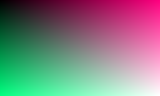

In [11]:
// Build a simple RGB gradient tensor and display it with a caption.
let h = 96; let w = 160;
let mut r = Vec::with_capacity(h*w);
let mut g = Vec::with_capacity(h*w);
let mut b = Vec::with_capacity(h*w);
for y in 0..h {
  for x in 0..w {
    let fx = x as f32 / (w as f32 - 1.0);
    let fy = y as f32 / (h as f32 - 1.0);
    r.push(fx); g.push(fy); b.push( (fx+fy)/2.0 );
  }
}
let dev = Device::Cpu;
let r = Tensor::from_vec(r, (1,h,w), &dev).unwrap();
let g = Tensor::from_vec(g, (1,h,w), &dev).unwrap();
let b = Tensor::from_vec(b, (1,h,w), &dev).unwrap();
let rgb = Tensor::cat(&[r,g,b], 0).unwrap();
nb::show_tensor_rgb_captioned(&rgb, Some("RGB Gradient"), Some("fx, fy basis"), Some("r=fx g=fy b=(fx+fy)/2" ) ).unwrap();

Caption: Radial + Rings  Dims: 80×120


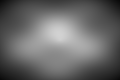

In [6]:
// Demonstrate grayscale tensor display.
let h = 80; let w = 120;
let mut v = Vec::with_capacity(h*w);
for y in 0..h {
  for x in 0..w {
    let fx = x as f32 / (w as f32 - 1.0);
    let fy = y as f32 / (h as f32 - 1.0);
    // Radial falloff + slight ring pattern
    let dx = fx - 0.5; let dy = fy - 0.5;
    let r = (dx*dx + dy*dy).sqrt();
    let val = (1.0 - r*1.35).max(0.0) * ( ( (fx*10.0).sin() * (fy*10.0).cos() )*0.15 + 0.85 );
    v.push(val);
  }
}
let dev = Device::Cpu;
let g = Tensor::from_vec(v, (h,w), &dev).unwrap();
nb::show_tensor_gray_captioned(&g, Some("Radial + Rings"), Some("procedural"), None).unwrap();

In [7]:
// Use the pseudo 'egui_window' to show a custom HTML block.
use nb::egui_window;
egui_window::open_text("Plain Text Window", "This is a placeholder window rendered as HTML.");
egui_window::open_color_squares("Color Squares");

Color Squares

In [8]:
// Example combining HTML body with inline image produced via data URL.
let dev = Device::Cpu;
let g = Tensor::rand(0.0, 1.0, (3, 48, 48), &dev).unwrap();
let url = nb::tensor_to_png_data_url_rgb(&g).unwrap();
let html = format!("<p>Random noise (3x48x48)</p><img style='image-rendering:pixelated;border:1px solid #333;' src='{}'/>", url);
egui_window::open("Inline Image", &html);


thread '<unnamed>' panicked at src/lib.rs:111:46:
called `Result::unwrap()` on an `Err` value: unexpected dtype, expected: F32, got: F64
   0: candle_core::error::Error::bt
   1: <f32 as candle_core::dtype::WithDType>::cpu_storage_as_slice
   2: candle_core::tensor::Tensor::to_vec3::{{closure}}
   3: candle_core::tensor::Tensor::to_vec3
   4: candle_notebook::tensor_to_png_data_url_rgb
   5: std::panic::catch_unwind
   6: run_user_code_6
   7: evcxr::runtime::Runtime::run_loop
   8: evcxr::runtime::runtime_hook
   9: evcxr_jupyter::main
  10: std::sys::backtrace::__rust_begin_short_backtrace
  11: std::rt::lang_start::{{closure}}
  12: std::rt::lang_start_internal
  13: main
  14: __libc_start_call_main
             at ./csu/../sysdeps/nptl/libc_start_call_main.h:58:16
  15: __libc_start_main_impl
             at ./csu/../csu/libc-start.c:360:3
  16: _start


Stack backtrace:
   0: anyhow::error::<impl core::convert::From<E> for anyhow::Error>::from
   1: candle_notebook::tensor_to_pn